# Cat Vocalisation Classification – Workflow Plan

This notebook implements a full pipeline for analysing and classifying cat vocalisations by stimulus using both MFCC features and spectrogram representations. The workflow is structured to ensure traceability, reproducibility, and proper experimental design.

---

# Phase 1 – Dataset Metadata and Exploratory Data Analysis (EDA)

Goal: Understand the dataset structure before modelling.

Tasks:

- [ ] Build a metadata table containing:
  - File name
  - Class label (stimulus)
  - Cat ID
  - File path
  - Sample rate
  - Duration of recording

- [ ] Compute dataset statistics:
  - Total number of recordings
  - Number of cats
  - Number of classes
  - Number of recordings per class
  - Number of recordings per cat

- [ ] Analyse recording duration:
  - Minimum duration
  - Maximum duration
  - Mean duration
  - Median duration

- [ ] Visualise dataset properties:
  - Class distribution (bar chart)
  - Duration distribution (histogram)
  - Duration by class (boxplot)

Key questions to answer:
- Are classes balanced?
- Do some stimuli produce longer sounds?
- Are some cats over-represented?

---

# Phase 2 – Train/Test Split Strategy

Goal: Prevent data leakage and allow traceability of predictions.

Tasks:

- [ ] Perform train/test split before feature extraction
- [ ] Prefer splitting by cat ID to ensure the model is evaluated on unseen cats
- [ ] Store split membership in metadata:
  - train
  - test

Benefits:
- MFCCs and spectrograms remain linked to original files
- Misclassified samples can be traced back and listened to

---

# Phase 3 – Audio Preprocessing

Goal: Prepare audio signals for feature extraction.

Tasks:

- [ ] Convert stereo audio to mono
- [ ] Crop silence using energy threshold
- [ ] Resample audio to a consistent sampling rate
- [ ] Normalize amplitude
- [ ] Remove extremely short signals

---

# Phase 4 – Feature Extraction

Two parallel feature pipelines will be implemented.

---

## Pipeline A – MFCC Features

Tasks:

- [ ] Compute MFCC features for each recording
- [ ] Extract summary statistics:
  - Mean of MFCC coefficients
  - Standard deviation of MFCC coefficients
- [ ] Build feature matrix `X`
- [ ] Store labels `y`
- [ ] Keep file names linked to feature rows

---

## Pipeline B – Spectrogram Features

Tasks:

- [ ] Generate spectrograms for each recording
- [ ] Resize spectrogram images to consistent dimensions
- [ ] Store spectrogram representations
- [ ] Link spectrograms to original file names

Purpose:
- Allow models to learn directly from time–frequency representations.

---

# Phase 5 – Model Training

Goal: Compare multiple classifiers using the same dataset split.

Models to implement:

- [ ] Logistic Regression
- [ ] Support Vector Machine (SVM)
- [ ] Decision Tree
- [ ] Random Forest
- [ ] Extra Trees
- [ ] Gradient Boosting
- [ ] XGBoost
- [ ] Artificial Neural Network (ANN)
- [ ] Convolutional Neural Network (CNN) for spectrograms

Evaluation metrics:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

---

# Phase 6 – Model Interpretability

Goal: Understand which acoustic features influence predictions.

Tasks:

- [ ] Compute feature importances for:
  - Decision Tree
  - Random Forest
  - XGBoost

- [ ] Analyse which MFCC coefficients contribute most to classification

- [ ] Apply permutation importance where needed

---

# Phase 7 – Error Analysis

Goal: Understand model weaknesses.

Tasks:

- [ ] Identify misclassified recordings
- [ ] Trace predictions back to original files
- [ ] Listen to misclassified sounds
- [ ] Compare their spectrograms and MFCC patterns

Questions to investigate:
- Are some stimuli acoustically similar?
- Are errors associated with specific cats?
- Are some recordings noisy or ambiguous?

---

# Phase 8 – Ensemble Learning

Goal: Combine strong models to improve performance.

Tasks:

- [ ] Identify best-performing models
- [ ] Implement ensemble strategies:
  - Voting classifier
  - Stacking classifier

- [ ] Compare ensemble performance to individual models

---

# Phase 9 – Results Table for Dissertation

Goal: Present results clearly.

Tasks:

- [ ] Build a summary table including:
  - Model
  - Feature type (MFCC / Spectrogram)
  - Accuracy
  - Balanced Accuracy
  - Precision
  - Recall
  - F1-score

- [ ] Identify best-performing approach

---

# Phase 10 – Model Explanation (Dissertation Section)

For each model, provide a clear explanation of:

- How the model works
- Why it was selected
- Advantages
- Limitations
- Suitability for audio classification tasks

Models to explain:

- Logistic Regression
- SVM
- Decision Tree
- Random Forest
- XGBoost
- ANN
- CNN
- Ensemble methods

---

# Final Objective

Develop a robust classification pipeline that compares classical machine learning and deep learning approaches for recognising cat vocalisations across different stimuli.

### IMPORTING LIBRARIES

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disables Metal/GPU

In [63]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import librosa
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import GlobalAveragePooling2D

import IPython.display as ipd
from scipy.signal import spectrogram
import librosa
from skimage.transform import resize
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping




from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier



## PHASE 1

### BUILDING METADATA TABLE AND COMPUTING DURATIONS

In [3]:
# I define the path to my dataset
dataset_path = "dataset_split"

# I create an empty list to store metadata for each audio file
metadata = []

# I loop through each activity folder inside the dataset
for activity_label in sorted(os.listdir(dataset_path)):
    activity_path = os.path.join(dataset_path, activity_label)
    
    # I skip anything that is not a folder
    if not os.path.isdir(activity_path):
        continue
    
    # I loop through each WAV file inside the activity folder
    for file_name in sorted(os.listdir(activity_path)):
        if not file_name.lower().endswith(".wav"):
            continue
        
        file_path = os.path.join(activity_path, file_name)
        
        try:
            # I read the audio file
            sample_rate, audio = wavfile.read(file_path)
            
            # I count the number of samples
            num_samples = len(audio)
            
            # I compute the duration in seconds
            duration_sec = num_samples / sample_rate
            
            # I store all useful metadata in a dictionary
            metadata.append({
                "file_name": file_name,
                "file_path": file_path,
                "activity_label": activity_label,
                "sample_rate": sample_rate,
                "num_samples": num_samples,
                "duration_sec": duration_sec
            })
        
        except Exception as e:
            print(f"I could not process {file_name}: {e}")

# I convert the list of dictionaries into a DataFrame
metadata_df = pd.DataFrame(metadata)

# I display the first few rows
print("Metadata table shape:", metadata_df.shape)
metadata_df.head()

Metadata table shape: (440, 6)


/var/folders/lf/j6_jcn1528n_kjn39d3gbfz80000gn/T/ipykernel_2159/1512601451.py:24: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio = wavfile.read(file_path)


,file_name,file_path,activity_label,sample_rate,num_samples,duration_sec
0,B_ANI01_MC_FN_SIM01_101.wav,dataset_split/brushing/B_ANI01_MC_FN_SIM01_101...,brushing,8000,18252,2.281500
1,B_ANI01_MC_FN_SIM01_102.wav,dataset_split/brushing/B_ANI01_MC_FN_SIM01_102...,brushing,8000,11352,1.419000
2,B_ANI01_MC_FN_SIM01_103.wav,dataset_split/brushing/B_ANI01_MC_FN_SIM01_103...,brushing,8000,14391,1.798875
3,B_ANI01_MC_FN_SIM01_301.wav,dataset_split/brushing/B_ANI01_MC_FN_SIM01_301...,brushing,8000,13916,1.739500
4,B_ANI01_MC_FN_SIM01_302.wav,dataset_split/brushing/B_ANI01_MC_FN_SIM01_302...,brushing,8000,10144,1.268000


### Basic Checks and Sumary Statistics

In [4]:

# I print the total number of recordings
print("\nTotal number of recordings:", len(metadata_df))

# I print the unique activity classes
print("\nActivity classes:", metadata_df["activity_label"].unique())

# I count the number of recordings per activity
print("\nRecordings per activity:")
print(metadata_df["activity_label"].value_counts())

# I compute overall duration statistics
print("\nOverall duration statistics:")
print(metadata_df["duration_sec"].describe())


Total number of recordings: 440

Activity classes: ['brushing' 'food' 'isolation']

Recordings per activity:
activity_label
isolation    221
brushing     127
food          92
Name: count, dtype: int64

Overall duration statistics:
count    440.000000
mean       1.831099
std        0.361251
min        1.085500
25%        1.635219
50%        1.809562
75%        1.981500
max        4.001500
Name: duration_sec, dtype: float64


### Duration Statistics by Activity

In [5]:
# I summarise recording duration for each activity class
duration_by_activity = metadata_df.groupby("activity_label")["duration_sec"].describe()

print("Duration statistics by activity:")
print(duration_by_activity)

Duration statistics by activity:
                count      mean       std       min       25%       50%  \
activity_label                                                            
brushing        127.0  1.845468  0.491244  1.106625  1.556062  1.806250   
food             92.0  1.641125  0.269968  1.085500  1.428844  1.608437   
isolation       221.0  1.901927  0.267959  1.221250  1.736125  1.865500   

                     75%       max  
activity_label                      
brushing        1.936688  4.001500  
food            1.798875  2.302875  
isolation       2.027000  2.934625  


This dataset contains 440 labelled cat vocalisations across three behavioural contexts. Class distribution is imbalanced, with isolation calls forming half of all recordings. Duration analysis shows that most vocalisations are short (≈1.8 seconds) with limited variability, although brushing sounds exhibit greater duration spread. These characteristics indicate a relatively homogeneous dataset in terms of temporal length but with notable class imbalance, which may influence model training dynamics.

### EDA

#### 1. Class Distribution

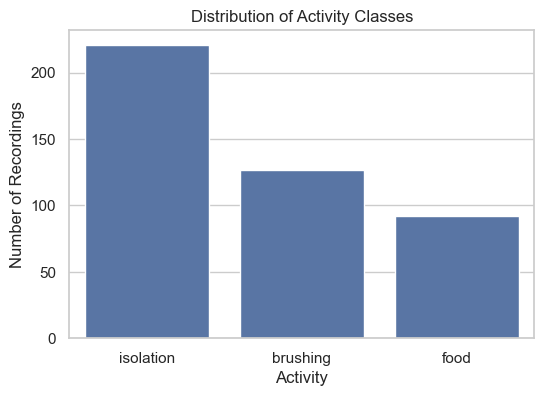

In [6]:


# I set the plotting style for clearer visuals
sns.set(style="whitegrid")

# I plot the number of recordings per activity
plt.figure(figsize=(6,4))
sns.countplot(data=metadata_df, x="activity_label", order=metadata_df["activity_label"].value_counts().index)

plt.title("Distribution of Activity Classes")
plt.xlabel("Activity")
plt.ylabel("Number of Recordings")

plt.show()

#### 2. Recording Duration Histogram

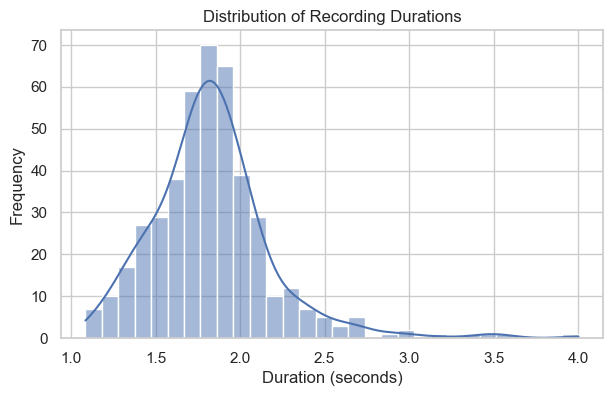

In [7]:
# I plot the distribution of recording durations
plt.figure(figsize=(7,4))

sns.histplot(metadata_df["duration_sec"], bins=30, kde=True)

plt.title("Distribution of Recording Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

#### 3. Duration by Activity

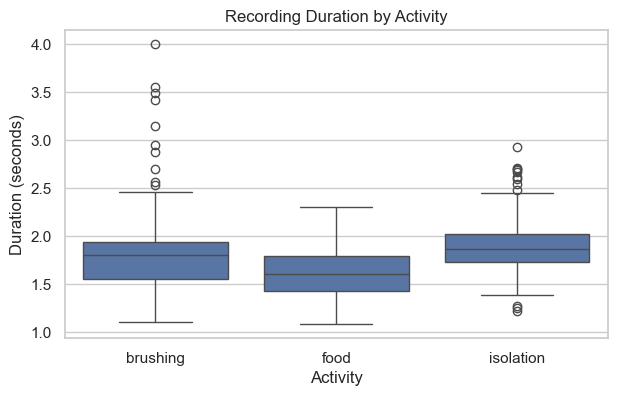

In [8]:
# I compare recording duration across activity classes
plt.figure(figsize=(7,4))

sns.boxplot(data=metadata_df, x="activity_label", y="duration_sec")

plt.title("Recording Duration by Activity")
plt.xlabel("Activity")
plt.ylabel("Duration (seconds)")

plt.show()

In [9]:
def crop_active_region(signal, sr, frame_size=2048, hop=512, energy_threshold_ratio=0.1):
    # I ensure signal is a 1D float array (mono)
    if signal is None:
        return np.array([], dtype=np.float32)

    signal = np.asarray(signal)

    # If stereo (2 channels), I convert to mono
    if signal.ndim == 2:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float32)

    # If empty or too short to frame, I do nothing
    if signal.size == 0 or signal.size < frame_size:
        return signal

    # I compute energy per frame
    energy = compute_energy(signal, frame_size, hop)

    # If compute_energy produced nothing, I do nothing
    if energy is None or len(energy) == 0:
        return signal

    emax = np.max(energy)

    # If all-zero energy (silence), I do nothing
    if not np.isfinite(emax) or emax <= 0:
        return signal

    threshold = energy_threshold_ratio * emax

    active_frames = np.where(energy > threshold)[0]
    if len(active_frames) == 0:
        # Nothing above threshold → keep original
        return signal

    start_frame = active_frames[0]
    end_frame = active_frames[-1]

    start = start_frame * hop
    end = min(end_frame * hop + frame_size, len(signal))

    return signal[start:end]

In [10]:
def compute_energy(signal, frame_size=1024, hop=512):
    """
    Break audio into small chunks and compute energy of each chunk.
    Energy tells us where sound is loud vs silent.
    """
    energy = []

    for i in range(0, len(signal) - frame_size, hop):
        frame = signal[i:i+frame_size]
        e = np.sum(frame**2)        # energy = squared amplitude
        energy.append(e)

    return np.array(energy)


/var/folders/lf/j6_jcn1528n_kjn39d3gbfz80000gn/T/ipykernel_2159/2445668006.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, audio = wavfile.read(sample_row["file_path"])


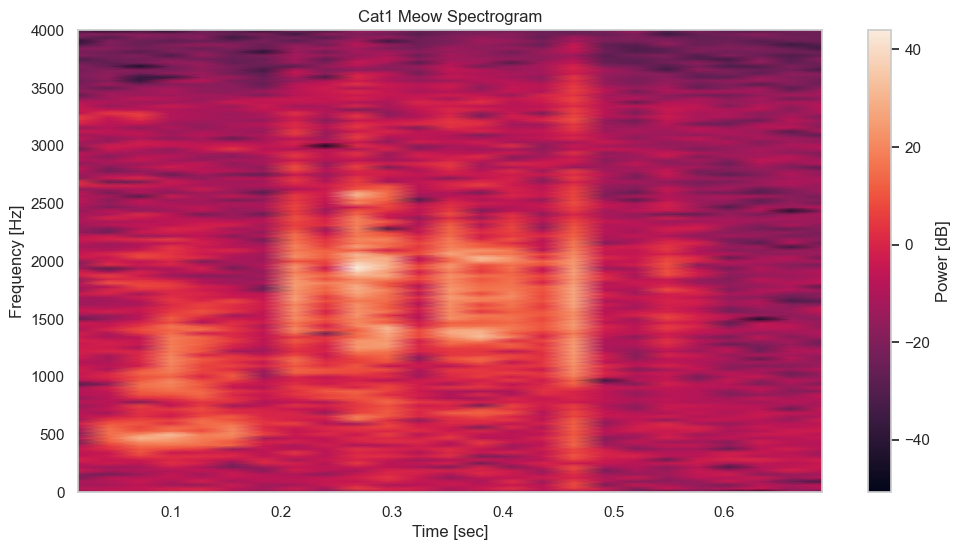

In [11]:
sample_row = metadata_df.iloc[1]

sr, audio = wavfile.read(sample_row["file_path"])

cropped = crop_active_region(audio, sr)

# 2. Recompute spectrogram on the cropped signal
f, t, Sxx = spectrogram(cropped, sr)

# 3. Convert to dB
Sxx_db = 10 * np.log10(Sxx + 1e-10)

# 4. Plot
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx_db, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Cat1 Meow Spectrogram')
plt.colorbar(label='Power [dB]')
plt.ylim(0, sr/2)
plt.show()


## PHASE 2

### Train/Test Split

#### 1. Performing Stratified Train/Test Split

In [12]:


# I split the dataset while preserving the class distribution
train_df, test_df = train_test_split(
    metadata_df,
    test_size=0.2,                    # 80% train, 20% test
    stratify=metadata_df["activity_label"],
    random_state=42
)

# I add a column indicating the dataset split
train_df["split"] = "train"
test_df["split"] = "test"

# I combine them again for traceability
metadata_split_df = pd.concat([train_df, test_df]).reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 352
Test size: 88


#### 2. Verifying class distribution after split

In [13]:
print("\nTrain class distribution:")
print(train_df["activity_label"].value_counts())

print("\nTest class distribution:")
print(test_df["activity_label"].value_counts())


Train class distribution:
activity_label
isolation    177
brushing     101
food          74
Name: count, dtype: int64

Test class distribution:
activity_label
isolation    44
brushing     26
food         18
Name: count, dtype: int64


#### 3. Saving file lists later for Feature Extraction

In [14]:
# I create lists of file paths for training and testing
train_files = train_df["file_path"].tolist()
test_files = test_df["file_path"].tolist()

print("Number of training files:", len(train_files))
print("Number of testing files:", len(test_files))

Number of training files: 352
Number of testing files: 88


#### 4. Saving the split metadata

In [15]:
metadata_split_df.to_csv("dataset_metadata_with_split.csv", index=False)

## PHASE 3

### MFCC Feature Extraction Pipeline (Classical ML)

In [16]:
# I define sample rate and feature containers
target_sr = 16000

X_train_mfcc = []
y_train_mfcc = []

X_test_mfcc = []
y_test_mfcc = []

#### Energy Function

In [17]:
# I compute short-time energy of signal
def compute_energy(signal, frame_size=1024, hop=512):
    energy = []
    
    for i in range(0, len(signal) - frame_size, hop):
        frame = signal[i:i+frame_size]
        energy.append(np.sum(frame**2))
    
    return np.array(energy)

### Cropping

In [18]:
# I crop only active sound regions
def crop_active_region(signal, sr, frame_size=2048, hop=512, energy_threshold_ratio=0.03):

    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim == 2:
        signal = signal.mean(axis=1)

    if len(signal) < frame_size:
        return signal

    energy = compute_energy(signal, frame_size, hop)

    if len(energy) == 0:
        return signal

    threshold = energy_threshold_ratio * np.max(energy)
    active = np.where(energy > threshold)[0]

    if len(active) == 0:
        return signal

    start = max(active[0] - 2, 0) * hop
    end = min(active[-1] + 2, len(energy)-1) * hop

    return signal[start:end]

### Building Train

In [19]:
# I extract MFCC features for training data
for _, row in train_df.iterrows():

    try:
        audio, sr = librosa.load(row["file_path"], sr=None)

        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        audio = crop_active_region(audio, sr)

        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

        feature = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        X_train_mfcc.append(feature)
        y_train_mfcc.append(row["activity_label"])

    except Exception as e:
        print("Train MFCC error:", e)

#### MFCC Test

In [20]:
# I extract MFCC features for test data
for _, row in test_df.iterrows():

    try:
        audio, sr = librosa.load(row["file_path"], sr=None)

        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        audio = crop_active_region(audio, sr)

        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

        feature = np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1)
        ])

        X_test_mfcc.append(feature)
        y_test_mfcc.append(row["activity_label"])

    except Exception as e:
        print("Test MFCC error:", e)

### MFCC Array Conversion

In [21]:
# I convert MFCC lists to arrays
X_train_mfcc = np.array(X_train_mfcc)
X_test_mfcc = np.array(X_test_mfcc)

y_train_mfcc = np.array(y_train_mfcc)
y_test_mfcc = np.array(y_test_mfcc)

print(X_train_mfcc.shape, X_test_mfcc.shape)

(352, 26) (88, 26)


### Spectogram Feature Extraction Pipeline CNN/Image Based)


In this section I generate spectrogram representations for each audio recording after the train/test split.

For each recording, I want  to :

- Load the audio file
- Convert stereo to mono if necessary
- Crop silent regions
- Resample to a fixed sample rate
- Normalize the signal
- Generate a spectrogram
- Convert the spectrogram to log scale
- Resize the spectrogram to a consistent image size
- Store the spectrogram array together with its activity label and file path

These spectrograms will later be used to train a CNN for image-based classification.

In [22]:
# I create mel spectrogram images
def make_clean_spectrogram(file_path, target_sr=16000, duration=3):

    audio, sr = librosa.load(file_path, sr=None)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

    max_len = target_sr * duration

    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=target_sr,
        n_fft=1024,
        hop_length=256,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    mel_min, mel_max = mel_db.min(), mel_db.max()
    mel = (mel_db - mel_min) / (mel_max - mel_min + 1e-6)

    return mel

#### Buildng Dataset

In [23]:
# I build spectrogram dataset
def build_dataset(df):
    X, y = [], []

    for _, row in df.iterrows():
        try:
            spec = make_clean_spectrogram(row["file_path"])
            X.append(spec)
            y.append(row["activity_label"])
        except Exception as e:
            print("Error:", e)

    return np.array(X), np.array(y)


X_train_spec, y_train_spec = build_dataset(train_df)
X_test_spec, y_test_spec = build_dataset(test_df)

### CNN Input

In [24]:
# I add channel dimension
X_train_spec = X_train_spec[..., np.newaxis]
X_test_spec = X_test_spec[..., np.newaxis]

### Label Encoding

In [25]:
# I encode labels consistently for spectrogram CNN
spec_label_encoder = LabelEncoder()

y_train_enc = spec_label_encoder.fit_transform(y_train_spec)
y_test_enc = spec_label_encoder.transform(y_test_spec)

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

#### Visualization

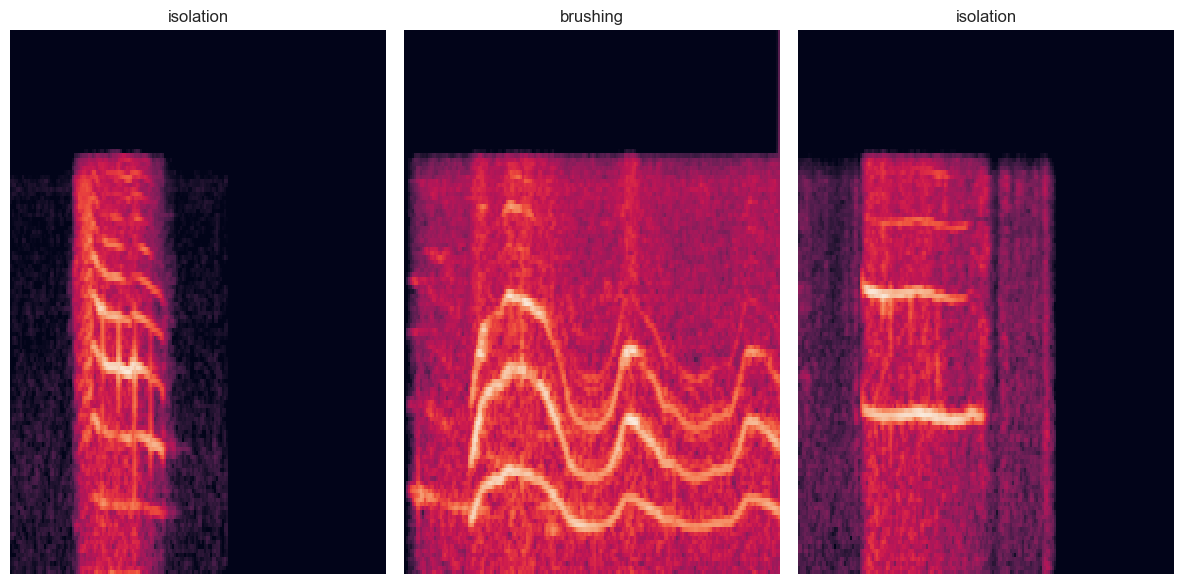

In [26]:
# I visualise sample spectrograms
plt.figure(figsize=(12, 6))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_train_spec[i].squeeze(), origin="lower", aspect="auto")
    plt.title(y_train_spec[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### MFCC Models

In [27]:

# I encode my string labels into numeric form
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_mfcc)
y_test_enc = label_encoder.transform(y_test_mfcc)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            C=2.0,
            solver="lbfgs",
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            C=10,
            gamma=0.05,
            probability=False,
            random_state=42
        ))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=3,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        random_state=42
    )
}


In [28]:
# I create an empty list to store model results
results = []

# I train and evaluate each model using the same procedure
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    model.fit(X_train_mfcc, y_train_enc)
    y_pred = model.predict(X_test_mfcc)
    
    acc = accuracy_score(y_test_enc, y_pred)
    bal_acc = balanced_accuracy_score(y_test_enc, y_pred)
    precision = precision_score(y_test_enc, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test_enc, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average="weighted", zero_division=0)
    
    results.append({
        "Model": model_name,
        "Feature Type": "MFCC",
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })




Training Logistic Regression...

Training SVM...

Training Decision Tree...

Training Random Forest...

Training Extra Trees...

Training Gradient Boosting...


In [29]:
# I convert results to a dataframe for easier comparison
results_df = pd.DataFrame(results)

# I sort the table by balanced accuracy because the classes are imbalanced
results_df = results_df.sort_values(by="Balanced Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Feature Type,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,SVM,MFCC,0.772727,0.740417,0.774619,0.772727,0.772516
1,Extra Trees,MFCC,0.761364,0.711862,0.757461,0.761364,0.755264
2,Random Forest,MFCC,0.704545,0.635910,0.692614,0.704545,0.696883
3,Gradient Boosting,MFCC,0.681818,0.632155,0.674249,0.681818,0.677002
4,Logistic Regression,MFCC,0.659091,0.621795,0.668304,0.659091,0.662261
5,Decision Tree,MFCC,0.500000,0.456682,0.532719,0.500000,0.512879


### 2. Phase 5 – XGBoost Model

In this section I train XGBoost separately because it requires its own implementation and supports strong non-linear learning for tabular features.

XGBoost is included because it is often one of the strongest models for structured data and may outperform standard tree ensembles.

In [30]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),

    # Boosting strength
    n_estimators=800,          # more trees, but with strong regularisation
    learning_rate=0.02,        # slower learning = better generalisation

    # Tree structure
    max_depth=6,               # deeper trees capture MFCC interactions
    min_child_weight=4,        # prevents overfitting small patterns
    gamma=0.25,                # requires meaningful splits

    # Subsampling (critical for small datasets)
    subsample=0.8,             # row sampling
    colsample_bytree=0.7,      # feature sampling

    # Regularisation
    reg_alpha=1.0,             # L1 sparsity (removes weak MFCCs)
    reg_lambda=1.5,            # L2 stabilisation

    # Multi-class evaluation
    eval_metric="mlogloss",
    random_state=42
)


In [31]:
# I train XGBoost
xgb_model.fit(X_train_mfcc, y_train_enc)



,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [32]:
# I make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_mfcc)

# I compute evaluation metrics
xgb_result = {
    "Model": "XGBoost",
    "Feature Type": "MFCC",
    "Accuracy": accuracy_score(y_test_enc, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test_enc, y_pred_xgb),
    "Precision": precision_score(y_test_enc, y_pred_xgb, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_enc, y_pred_xgb, average="weighted", zero_division=0),
    "F1-score": f1_score(y_test_enc, y_pred_xgb, average="weighted", zero_division=0)
}



In [33]:


# I identify the best model based on balanced accuracy
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on balanced accuracy:", best_model_name)

# I retrieve the corresponding trained model
if best_model_name == "XGBoost":
    best_model = xgb_model
else:
    best_model = models[best_model_name]

# I generate predictions from the best model
y_pred_best = best_model.predict(X_test_mfcc)

# I print the classification report using the original class names
print(classification_report(y_test_enc, y_pred_best, target_names=label_encoder.classes_))

Best model based on balanced accuracy: SVM
              precision    recall  f1-score   support

    brushing       0.69      0.77      0.73        26
        food       0.69      0.61      0.65        18
   isolation       0.86      0.84      0.85        44

    accuracy                           0.77        88
   macro avg       0.75      0.74      0.74        88
weighted avg       0.77      0.77      0.77        88




Training Logistic Regression...

Training SVM...


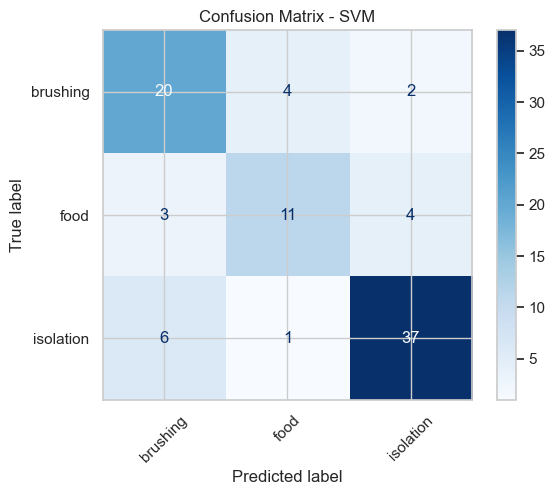


Training Decision Tree...

Training Random Forest...

Training Extra Trees...

Training Gradient Boosting...


In [66]:


for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    model.fit(X_train_mfcc, y_train_enc)
    y_pred = model.predict(X_test_mfcc)

    if model_name == "SVM":
        cm = confusion_matrix(y_test_enc, y_pred)
        
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=label_encoder.classes_
        )
        
        disp.plot(cmap="Blues", xticks_rotation=45)
        plt.title("Confusion Matrix - SVM")
        plt.show()

### CNN Model

In [34]:
# I build CNN model
cnn_model = Sequential([
    Conv2D(16, (3,3), padding="same", activation="relu",
           input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.4),
    
    Conv2D(16, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.4),


    GlobalAveragePooling2D(),

    Dense(32, activation="relu"),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation="softmax")
])

/Users/dell/miniforge3/envs/tf_macos/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-03 04:17:45.964559: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-03 04:17:45.964587: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-03 04:17:45.964590: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-03 04:17:45.964604: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-03 04:17:45.964611: I tensorflow/core/common_runtime/pluggable_device/pluggable_de

### Compiling

In [35]:
# I compile my CNN model
cnn_model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
# I save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# I stop training early if validation stops improving
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=30,
    restore_best_weights=True
)

In [37]:
# I train my CNN model on spectrogram data
history = cnn_model.fit(
    X_train_spec,
    y_train_cat,
    validation_split=0.2,
    epochs=80,
    batch_size=8,
    shuffle=True,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/80


2026-05-03 04:17:46.434394: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3387 - loss: 1.4905
Epoch 1: val_accuracy improved from None to 0.53521, saving model to best_cnn_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3060 - loss: 1.5168 - val_accuracy: 0.5352 - val_loss: 1.0801
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3050 - loss: 1.4547
Epoch 2: val_accuracy did not improve from 0.53521
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3310 - loss: 1.3937 - val_accuracy: 0.5352 - val_loss: 1.0910
Epoch 3/80
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3509 - loss: 1.3288
Epoch 3: val_accuracy did not improve from 0.53521
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3523 - loss: 1.3155 - val_accuracy: 0.5352 - val_loss: 1.1089
Epoch 4/80
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3698 - loss: 1.1566
Epoch 4: val_accuracy did not improve from 0.53521
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3203 - loss: 1.2469 - val_

#### Inspecting Example Spectrograms

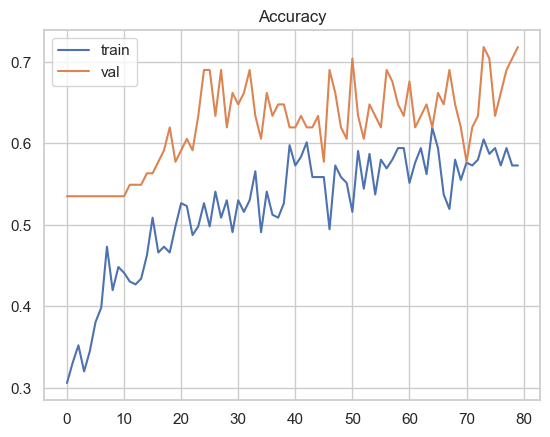

In [38]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train","val"])
plt.show()

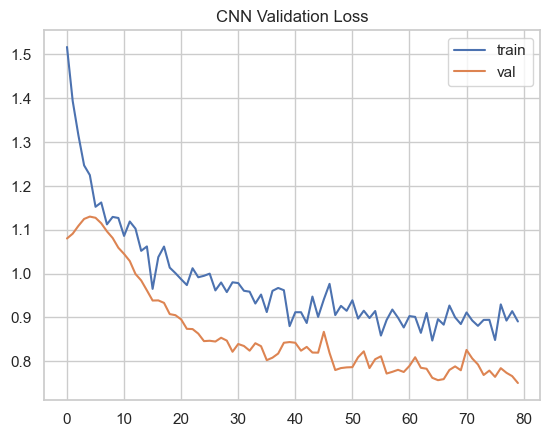

In [61]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("CNN Validation Loss")
plt.legend(["train","val"])
plt.show()

In [40]:
from tensorflow.keras.models import load_model

cnn_model = load_model("best_cnn_model.keras")  

In [41]:
# I generate predictions from my trained CNN model
y_pred_probs = cnn_model.predict(X_test_spec)

# I convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# I convert true labels to class indices
y_true = np.argmax(y_test_cat, axis=1)

# I compute metrics
accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

# I print results
print("CNN Results")
print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# I print classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=spec_label_encoder.classes_
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
CNN Results
Accuracy: 0.6363636363636364
Balanced Accuracy: 0.5795130795130795
Precision: 0.6376587901873587
Recall: 0.6363636363636364
F1-score: 0.6361862214250191
              precision    recall  f1-score   support

    brushing       0.52      0.58      0.55        26
        food       0.44      0.39      0.41        18
   isolation       0.79      0.77      0.78        44

    accuracy                           0.64        88
   macro avg       0.58      0.58      0.58        88
weighted avg       0.64      0.64      0.64        88



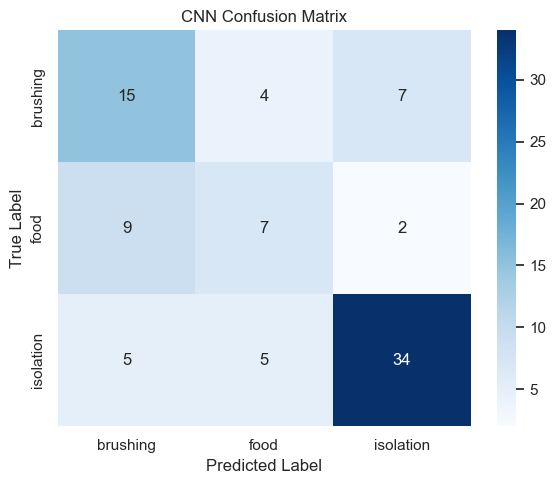

In [42]:
import seaborn as sns

# I compute the confusion matrix
cnn_cm = confusion_matrix(y_true, y_pred)

# I plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=spec_label_encoder.classes_,
    yticklabels=spec_label_encoder.classes_
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [43]:
# I create a result row for the CNN model
cnn_result = {
    "Model": "CNN",
    "Feature Type": "Spectrogram",
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_acc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

# I append CNN results to the results table
results_df = pd.concat([results_df, pd.DataFrame([cnn_result])], ignore_index=True)

# I sort by balanced accuracy for fair comparison
results_df = results_df.sort_values(by="Balanced Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Feature Type,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,SVM,MFCC,0.772727,0.740417,0.774619,0.772727,0.772516
1,Extra Trees,MFCC,0.761364,0.711862,0.757461,0.761364,0.755264
2,Random Forest,MFCC,0.704545,0.635910,0.692614,0.704545,0.696883
3,Gradient Boosting,MFCC,0.681818,0.632155,0.674249,0.681818,0.677002
4,Logistic Regression,MFCC,0.659091,0.621795,0.668304,0.659091,0.662261
5,CNN,Spectrogram,0.636364,0.579513,0.637659,0.636364,0.636186
6,Decision Tree,MFCC,0.500000,0.456682,0.532719,0.500000,0.512879


## PHASE 6

### Feature Importance and Model Interpretability

In this section I analyse feature importance to understand which MFCC features contribute most to predicting the activity class.

This analysis is performed using tree-based models because they naturally provide feature importance scores.

The models used are:

- Decision Tree
- Random Forest
- Extra Trees
- XGBoost

The MFCC feature set consists of:

- 13 MFCC mean coefficients
- 13 MFCC standard deviation coefficients



In [47]:


# I define the feature names corresponding to the MFCC statistics
feature_names = [f"MFCC{i+1}_mean" for i in range(13)] + [f"MFCC{i+1}_std" for i in range(13)]

# I create a dictionary to store feature importances from different models
feature_importances = {}




# Decision Tree
if "Decision Tree" in models:
    dt_model = models["Decision Tree"]
    feature_importances["Decision Tree"] = dt_model.feature_importances_

# Random Forest
if "Random Forest" in models:
    rf_model = models["Random Forest"]
    feature_importances["Random Forest"] = rf_model.feature_importances_

# Extra Trees
if "Extra Trees" in models:
    et_model = models["Extra Trees"]
    feature_importances["Extra Trees"] = et_model.feature_importances_

# XGBoost
feature_importances["XGBoost"] = xgb_model.feature_importances_

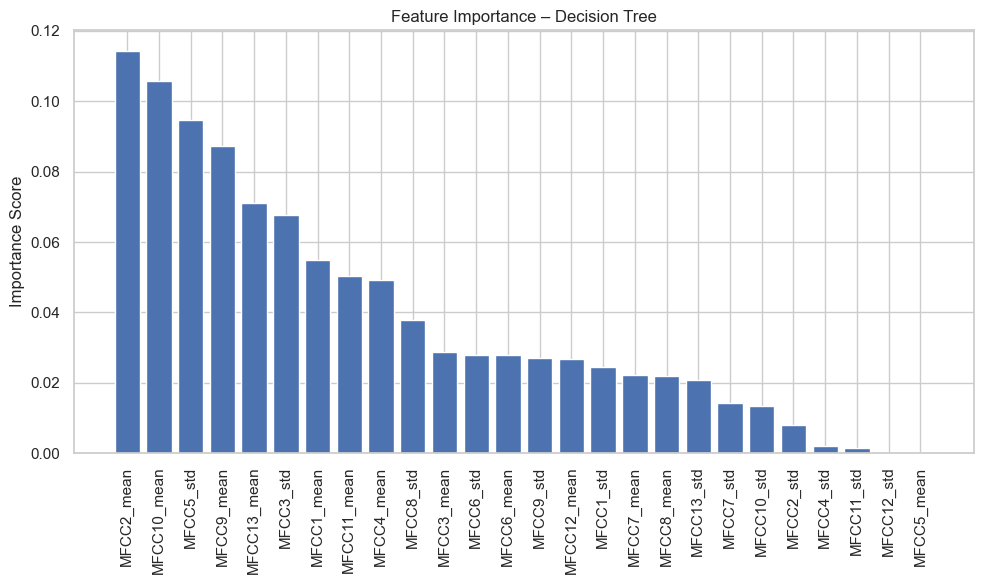

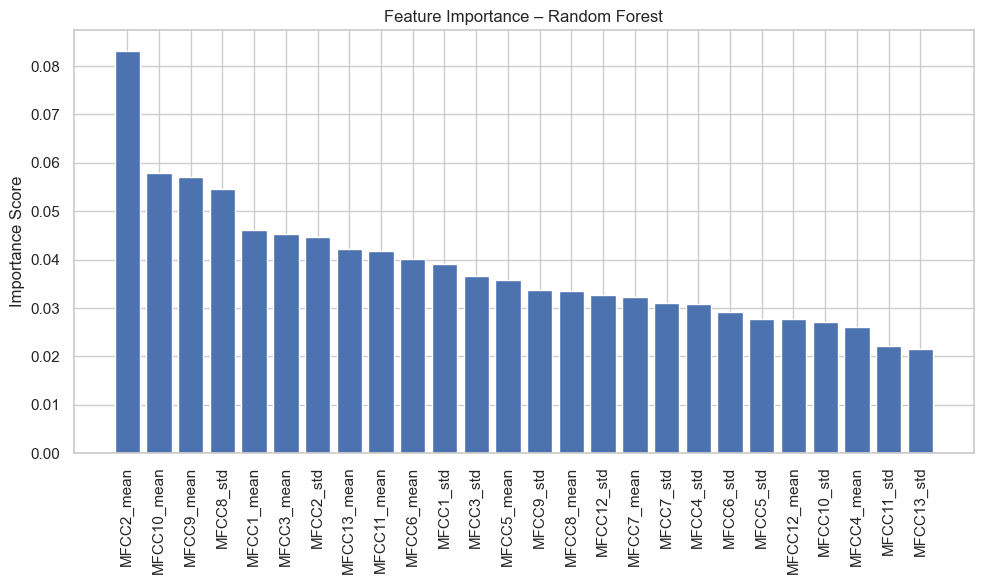

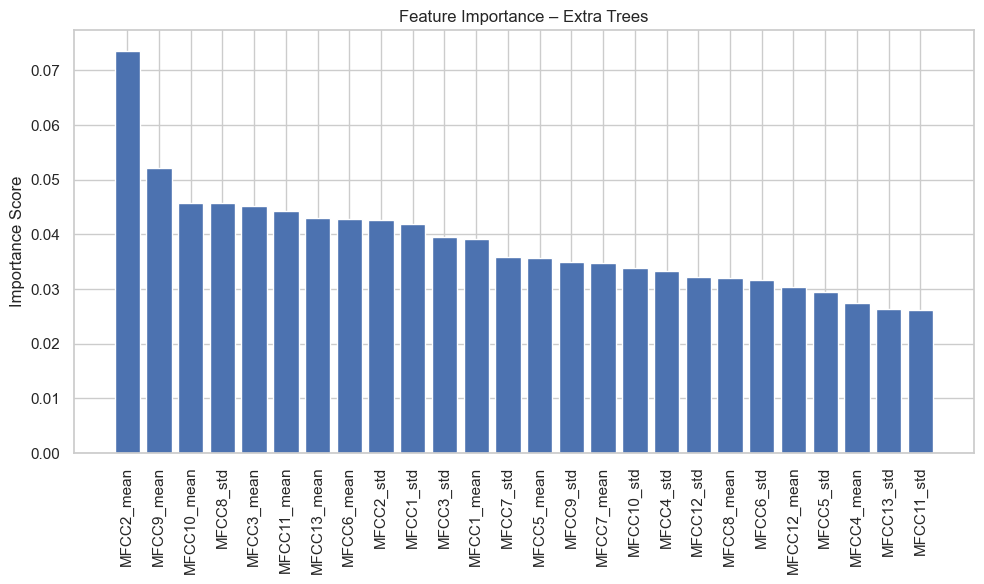

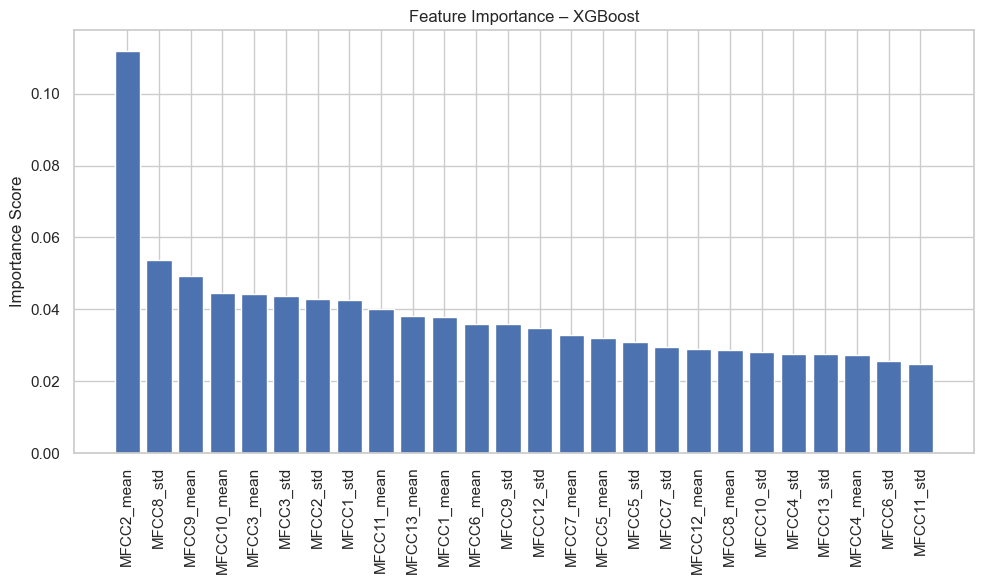

In [48]:
# I plot feature importance for each model
for model_name, importances in feature_importances.items():
    
    # I sort features by importance
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10,6))
    
    plt.title(f"Feature Importance – {model_name}")
    
    plt.bar(
        range(len(importances)),
        importances[indices]
    )
    
    plt.xticks(
        range(len(importances)),
        np.array(feature_names)[indices],
        rotation=90
    )
    
    plt.ylabel("Importance Score")
    
    plt.tight_layout()
    plt.show()

## PHASE 7

### Error Analysis

In this phase I will analyse the errors made by the best-performing model.

The objective is to understand where and why the model fails by examining misclassified recordings.

For each misclassification I will:

- Identify the predicted label
- Identify the true label
- Trace the prediction back to the original audio file
- Listen to the recording
- Visualise its spectrogram



In [49]:


# I generate predictions from the best model
y_pred_best = best_model.predict(X_test_mfcc)

# I build a dataframe linking predictions to the original files
error_analysis_df = test_df.copy()

# I add prediction columns
error_analysis_df["true_label"] = y_test_mfcc
error_analysis_df["predicted_label"] = label_encoder.inverse_transform(y_pred_best)

# I flag whether each prediction is correct
error_analysis_df["correct_prediction"] = (
    error_analysis_df["true_label"] == error_analysis_df["predicted_label"]
)

# I extract only the misclassified recordings
misclassified_df = error_analysis_df[error_analysis_df["correct_prediction"] == False]

print("Number of misclassified recordings:", len(misclassified_df))

misclassified_df.head()

Number of misclassified recordings: 20


,file_name,file_path,activity_label,sample_rate,num_samples,duration_sec,split,true_label,predicted_label,correct_prediction
161,F_IND01_EU_FN_ELI01_104.wav,dataset_split/food/F_IND01_EU_FN_ELI01_104.wav,food,8000,11349,1.418625,test,food,brushing,False
20,B_BRI01_MC_FI_SIM01_102.wav,dataset_split/brushing/B_BRI01_MC_FI_SIM01_102...,brushing,8000,12009,1.501125,test,brushing,food,False
212,F_WHO01_MC_FI_SIM01_103.wav,dataset_split/food/F_WHO01_MC_FI_SIM01_103.wav,food,8000,13640,1.705000,test,food,isolation,False
131,F_BAC01_MC_MN_SIM01_105.wav,dataset_split/food/F_BAC01_MC_MN_SIM01_105.wav,food,8000,11524,1.440500,test,food,brushing,False
438,I_WHO01_MC_FI_SIM01_201.wav,dataset_split/isolation/I_WHO01_MC_FI_SIM01_20...,isolation,8000,16648,2.081000,test,isolation,brushing,False


In [50]:
# I display a sample of misclassified recordings
misclassified_df[[
    "file_name",
    "activity_label",
    "true_label",
    "predicted_label",
    "duration_sec"
]].head(10)

,file_name,activity_label,true_label,predicted_label,duration_sec
161,F_IND01_EU_FN_ELI01_104.wav,food,food,brushing,1.418625
20,B_BRI01_MC_FI_SIM01_102.wav,brushing,brushing,food,1.501125
212,F_WHO01_MC_FI_SIM01_103.wav,food,food,isolation,1.705000
131,F_BAC01_MC_MN_SIM01_105.wav,food,food,brushing,1.440500
438,I_WHO01_MC_FI_SIM01_201.wav,isolation,isolation,brushing,2.081000
405,I_SPI01_EU_MN_NAI01_102.wav,isolation,isolation,brushing,2.255625
363,I_MAG01_EU_FN_FED01_101.wav,isolation,isolation,brushing,2.005875
129,F_BAC01_MC_MN_SIM01_103.wav,food,food,brushing,1.444375
421,I_TIG01_EU_FN_GIU01_203.wav,isolation,isolation,brushing,1.627875
311,I_CLE01_EU_FN_FER01_101.wav,isolation,isolation,food,2.026125


In [51]:


# I listen to a few misclassified recordings
for _, row in misclassified_df.head(3).iterrows():
    
    print("File:", row["file_name"])
    print("True label:", row["true_label"])
    print("Predicted label:", row["predicted_label"])
    
    display(ipd.Audio(row["file_path"]))

File: F_IND01_EU_FN_ELI01_104.wav
True label: food
Predicted label: brushing


File: B_BRI01_MC_FI_SIM01_102.wav
True label: brushing
Predicted label: food


File: F_WHO01_MC_FI_SIM01_103.wav
True label: food
Predicted label: isolation


### Spectrogram Analysis of Misclassified Recordings

To further analyse errors, I visualise the spectrogram of misclassified recordings.

This helps identify acoustic patterns that may confuse the model.

/var/folders/lf/j6_jcn1528n_kjn39d3gbfz80000gn/T/ipykernel_2159/2537715881.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, audio = wavfile.read(row["file_path"])


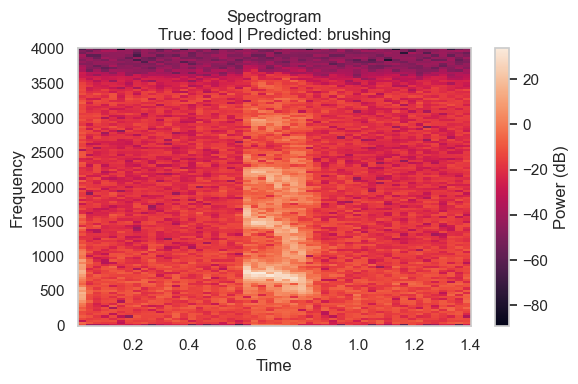

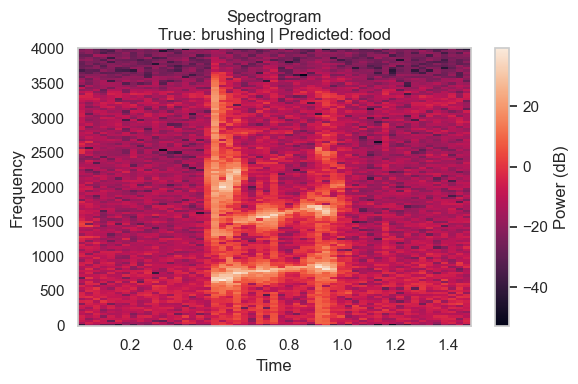

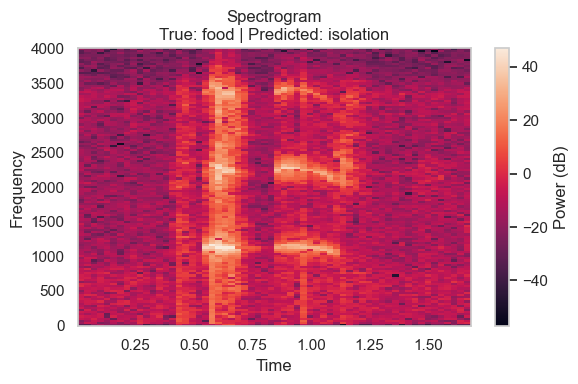

In [52]:
# I plot spectrograms for a few misclassified recordings
for _, row in misclassified_df.head(3).iterrows():
    
    sr, audio = wavfile.read(row["file_path"])
    
    f, t, Sxx = spectrogram(audio, sr)
    
    plt.figure(figsize=(6,4))
    plt.title(f"Spectrogram\nTrue: {row['true_label']} | Predicted: {row['predicted_label']}")
    plt.pcolormesh(t, f, 10 * np.log10(Sxx))
    plt.ylabel("Frequency")
    plt.xlabel("Time")
    plt.colorbar(label="Power (dB)")
    plt.tight_layout()
    plt.show()

### MY OBSERVATION:

The model wrongly predicted Isolation more thsn any class probably because Isolation dominate the datadset 50%

Other factores i should consider:
- Whether food vs Isolation saounds familiar
- Whether brushing vs Isolation saounds familiar

## PHASE 8

### Ensemble Learning

In this phase I combine the best-performing models to build ensemble classifiers.

The motivation behind ensemble learning is that different models often capture different patterns in the data. By combining their predictions, the ensemble may achieve better generalisation than any single model.

Two ensemble strategies are implemented:

1. Voting Classifier
   - Combines predictions from several models
   - Final prediction is based on majority vote

2. Stacking Classifier
   - Uses predictions from multiple base models as input to a meta-model
   - The meta-model learns how to combine these predictions optimally



### Preparing Base Models for the Esemble

In [53]:
# I define the base models for the ensemble
svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_model_ensemble = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=42
)

### Voting Ensemble

In [54]:
# I build a soft voting ensemble
voting_model = VotingClassifier(
    estimators=[
        ("svm", svm_model),
        ("rf", rf_model),
        ("xgb", xgb_model_ensemble)
    ],
    voting="soft"
)

# I train the ensemble
voting_model.fit(X_train_mfcc, y_train_enc)

# I generate predictions
y_pred_voting = voting_model.predict(X_test_mfcc)

### Evaluating the Voting Ensemble

In [55]:


voting_accuracy = accuracy_score(y_test_enc, y_pred_voting)
voting_bal_accuracy = balanced_accuracy_score(y_test_enc, y_pred_voting)
voting_precision = precision_score(y_test_enc, y_pred_voting, average="weighted", zero_division=0)
voting_recall = recall_score(y_test_enc, y_pred_voting, average="weighted", zero_division=0)
voting_f1 = f1_score(y_test_enc, y_pred_voting, average="weighted", zero_division=0)

print("Voting Ensemble Accuracy:", voting_accuracy)
print("Voting Ensemble Balanced Accuracy:", voting_bal_accuracy)

Voting Ensemble Accuracy: 0.7386363636363636
Voting Ensemble Balanced Accuracy: 0.6748251748251749


### Stacking Ensemble

In [56]:
# I define the stacking classifier
stacking_model = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("rf", rf_model),
        ("xgb", xgb_model_ensemble)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    n_jobs=-1
)

# I train the stacking ensemble
stacking_model.fit(X_train_mfcc, y_train_enc)

# I generate predictions
y_pred_stack = stacking_model.predict(X_test_mfcc)

### Evaluating the Stacking Ensemble

In [57]:
stack_accuracy = accuracy_score(y_test_enc, y_pred_stack)
stack_bal_accuracy = balanced_accuracy_score(y_test_enc, y_pred_stack)
stack_precision = precision_score(y_test_enc, y_pred_stack, average="weighted", zero_division=0)
stack_recall = recall_score(y_test_enc, y_pred_stack, average="weighted", zero_division=0)
stack_f1 = f1_score(y_test_enc, y_pred_stack, average="weighted", zero_division=0)

print("Stacking Ensemble Accuracy:", stack_accuracy)
print("Stacking Ensemble Balanced Accuracy:", stack_bal_accuracy)

Stacking Ensemble Accuracy: 0.75
Stacking Ensemble Balanced Accuracy: 0.7042864542864543


### Adding Ensemble Results to the Final Results Table

In [58]:
ensemble_results = [
    {
        "Model": "Voting Ensemble",
        "Feature Type": "MFCC",
        "Accuracy": voting_accuracy,
        "Balanced Accuracy": voting_bal_accuracy,
        "Precision": voting_precision,
        "Recall": voting_recall,
        "F1-score": voting_f1
    },
    {
        "Model": "Stacking Ensemble",
        "Feature Type": "MFCC",
        "Accuracy": stack_accuracy,
        "Balanced Accuracy": stack_bal_accuracy,
        "Precision": stack_precision,
        "Recall": stack_recall,
        "F1-score": stack_f1
    }
]

results_df = pd.concat([results_df, pd.DataFrame(ensemble_results)], ignore_index=True)

results_df = results_df.sort_values(by="Balanced Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Feature Type,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,SVM,MFCC,0.772727,0.740417,0.774619,0.772727,0.772516
1,Extra Trees,MFCC,0.761364,0.711862,0.757461,0.761364,0.755264
2,Stacking Ensemble,MFCC,0.750000,0.704286,0.748724,0.750000,0.748915
3,Voting Ensemble,MFCC,0.738636,0.674825,0.728693,0.738636,0.732162
4,Random Forest,MFCC,0.704545,0.635910,0.692614,0.704545,0.696883
5,Gradient Boosting,MFCC,0.681818,0.632155,0.674249,0.681818,0.677002
6,Logistic Regression,MFCC,0.659091,0.621795,0.668304,0.659091,0.662261
7,CNN,Spectrogram,0.636364,0.579513,0.637659,0.636364,0.636186
8,Decision Tree,MFCC,0.500000,0.456682,0.532719,0.500000,0.512879


## PHASE 9

### Final Model Comparison Table

In [59]:
# I identify the best-performing model based on balanced accuracy
best_model_row = results_df.iloc[0]

print("Best Model:", best_model_row["Model"])
print("Feature Representation:", best_model_row["Feature Type"])
print("Balanced Accuracy:", best_model_row["Balanced Accuracy"])

Best Model: SVM
Feature Representation: MFCC
Balanced Accuracy: 0.7404169904169904


### MFCC vs Spectrogram Performance Comparison

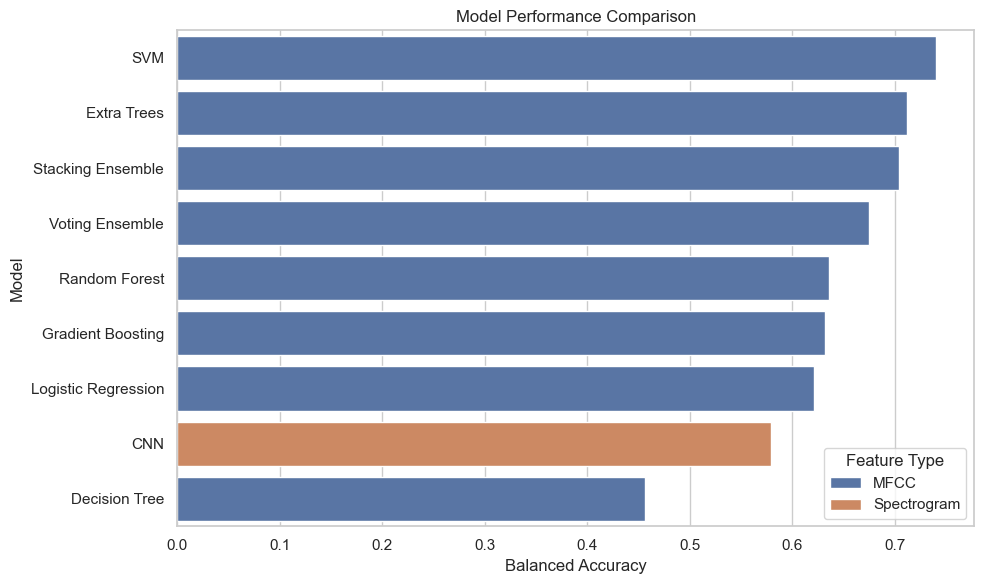

In [60]:


plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Balanced Accuracy",
    y="Model",
    hue="Feature Type"
)

plt.title("Model Performance Comparison")
plt.xlabel("Balanced Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()